## 0. Imports and Definitions

In [1]:
import json
import os
import copy
import torch
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

import scgen
import scanpy as sc

# Also applies a compat patch for scgen's SCGENVAE.inference() vs scvi-tools>=1.1's
# MODULE_KEYS ("qz_m"/"qz_v" -> "qz")
from src.model.SCGEN.SCGEN_model import SCGENMixturePriorWrapper

from src.model.data_utils import (
    prepare_train_test_data,
    load_data,
    load_metacells,
    prepare_data,
    get_condition_vocab,
    split_holdout_combinations,
)
from src.analysis.analysis_utils import Analyzer
from src.analysis.logistic_regression import (
    init_classifier,
    train_classifier,
    evaluate_training_error,
    evaluate_cfs_classification,
    generate_counterfactuals_scgen,
)
from src.analysis.mmd import ctrl_mmd_dists, mmd_dists, plot_mmd_dists
from src.analysis.cf_expressions import (
    plot_mean_expression_comparison,
    plot_effect_size_comparison,
    plot_top_deg_violin,
)
from src.analysis.INN_OOD import (
    estimate_leftout_combo_mean,
    scoped_analyzer_for_combo,
    cfs_fn_from_adata,
    evaluate_leftout_combo_mmd,
)

## 1. Load Data

In [2]:
dataset_args = {
    "dataset_name": "parse",
    "top_genes": 2000,
    "sigma_noise": 4,
    "batch_size": 512,
}

USE_METACELLS = True
DONOR = ["Donor1"]

if not USE_METACELLS:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=True,
        cell_types=["CD4 Memory"],
    )
else:
    # log_transform=False: scGen trains on .X directly (setup_anndata has no layer=
    # override below), so this must stay raw counts. load_metacells also skips
    # load_data entirely (not just SEACells) once a cache for this (dataset,
    # top_genes, donors, group_keys) combination exists on disk - shared with
    # eoflow.ipynb/mean.ipynb's own load_metacells calls regardless of their
    # different log_transform, since metacell construction never depends on it.
    adata, labels_key, control_label = load_metacells(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        ["cytokine", "cell_type"],
        donors=DONOR,
        log_transform=True,
    )
    print(adata.X.shape)

dataset_args["top_genes"] = min(adata.shape[1], dataset_args["top_genes"])
adata.obs["cluster_idx"] = adata.obs[f"{labels_key}"].astype("category").cat.codes

(12401, 1937)


In [ ]:
combo_conditions = [labels_key, "cell_type"]

# The same named combos train.py holds out (configs/holdout_combos.json), so scGen is
# trained on exactly the data EOFlow is and the two are compared on the same ten OOD
# combos. Ten rather than one is what gives every OOD metric an error bar: on a single
# combo of ~34 metacells the noise floor is nearly as large as the effect being measured.
# Set HOLDOUT_FILE = None to fall back to the single combo below.
HOLDOUT_FILE = "/home/jhoefer/sandbox/configs/holdout_combos.json"
HOLDOUT_COMBO = {labels_key: "IL-2", "cell_type": "CD8 Memory"}  # only if HOLDOUT_FILE is None

if HOLDOUT_FILE is not None:
    with open(HOLDOUT_FILE) as handle:
        HOLDOUT_COMBOS = json.load(handle)
    # the OOD sections below evaluate one combo; take it from the set rather than leaving
    # the hardcoded value, so it is guaranteed to be a combo training actually held out
    HOLDOUT_COMBO = next(iter(HOLDOUT_COMBOS.values()))
elif HOLDOUT_COMBO is not None:
    HOLDOUT_COMBOS = {"combo_1": HOLDOUT_COMBO}
else:
    HOLDOUT_COMBOS = {}

if HOLDOUT_COMBOS:
    assert USE_METACELLS, "Holding out combos requires USE_METACELLS=True."
    for name, combo in HOLDOUT_COMBOS.items():
        assert set(combo) == set(combo_conditions), f"{name}: {sorted(combo)} != {sorted(combo_conditions)}"

# fixed pre-holdout vocabulary, so every held-out combo still reserves a slot instead of
# vanishing once its rows are removed below
condition_categories, combo_categories = get_condition_vocab(adata, combo_conditions)

if HOLDOUT_COMBOS:
    train_adata, _ = split_holdout_combinations(
        adata, list(HOLDOUT_COMBOS.values()), group_keys=combo_conditions
    )
    listed = ", ".join(f"{k}={v[labels_key]} x {v['cell_type']}" for k, v in HOLDOUT_COMBOS.items())
    print(f"Held out {len(HOLDOUT_COMBOS)} combo(s): {listed}")
    print(f"Training on the remaining {train_adata.n_obs} of {adata.n_obs} metacells.")
else:
    train_adata = adata

model_path = "/g/stegle/jhoefer/models/scgen"
if HOLDOUT_FILE is not None:
    # named after the holdout SET, matching train.py's "_holdout_combos" suffix - the
    # per-combo string would be unusable at ten, and this keeps the new checkpoints from
    # colliding with the existing single-combo ones.
    stem = os.path.splitext(os.path.basename(HOLDOUT_FILE))[0]
    stem = stem[len("holdout_"):] if stem.startswith("holdout_") else stem
    model_path = os.path.join(model_path, f"holdout_{stem}")
elif HOLDOUT_COMBOS:
    combo_str = "_".join(f"{k}-{v.replace(' ', '-')}" for k, v in HOLDOUT_COMBO.items())
    model_path = os.path.join(model_path, f"holdout_{combo_str}")

## 2. Model

### 2.1 Training

In [4]:
scgen.SCGEN.setup_anndata(train_adata, batch_key=f"{labels_key}", labels_key="cell_type")
model = scgen.SCGEN(train_adata)
model.train(
    max_epochs=60,
    batch_size=128,
    early_stopping=True,
    early_stopping_patience=25
)

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jhoefer/sandbox/.venv/lib/python3.11/site-pack ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jhoefer/sandbox/.venv/lib/python3.11/site-pack ...


Training:   0%|          | 0/60 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 25 records. Best score: 1113.425. Signaling Trainer to stop.


In [5]:
os.makedirs(model_path, exist_ok=True)
model.save(os.path.join(model_path, "model.pt"), overwrite=True)

### 2.2 Loading

In [ ]:
model = scgen.SCGEN.load(os.path.join(model_path, "model.pt"), adata=train_adata)

## 3. Evaluation

### 3.1 Paths

In [7]:
plot_dir = f"/home/jhoefer/sandbox/results/scgen/plots/"
csv_dir = f"/home/jhoefer/sandbox/results/scgen/csv/"
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(csv_dir, exist_ok=True)

### 3.2 Clusters

In [ ]:
latent_X = model.get_latent_representation()
latent_adata = sc.AnnData(X=latent_X, obs=adata.obs.copy())

sc.pp.neighbors(latent_adata)
sc.tl.umap(latent_adata)
sc.pl.umap(latent_adata, color=[f'{labels_key}', 'cell_type'])

plt.tight_layout()
plt.savefig(f"{plot_dir}/scgen_umap.png", dpi=300)
plt.show()

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 100 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


KeyboardInterrupt: 

### 3.3 Counterfactuals

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

kwargs_data = {
    "device": device,
    "dtype": dtype,
    "sigma_noise": 0.0,
}

# built from train_adata (holdout-excluded), not the full adata - otherwise the held-out
# combo's real cells would get encoded straight into its own ".means" row, leaking ground
# truth into what the OOD section below estimates instead
wrapped_model = SCGENMixturePriorWrapper(
    model,
    train_adata,
    labels_key,
    conditions=combo_conditions,
    combo_categories=combo_categories,
)

analyzer = Analyzer(
    adata,
    wrapped_model,
    kwargs_data,
    labels_key,
    control_label,
    plot_dir,
    csv_dir,
    checkpoint_path=None,
    conditions=combo_conditions,
    condition_type=None,
)

In [9]:
key = "IL-2"

In [7]:
x_cfs, z_cfs, all_source_labels, _ = generate_counterfactuals_scgen(analyzer, key=key)
# x_cfs stays in raw-count scale (see SCGENMixturePriorWrapper.predict), matching
# analyzer.adata, so adata_real.X needs no conversion here.

adata_real = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key].copy()
adata_real.obs["origin"] = "original"

adata_cf = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] != key].copy()
adata_cf.X = x_cfs.numpy()
adata_cf.obs["origin"] = "cfs"
adata_cf.obs["source"] = all_source_labels  # keep track of where each cf came from

adata_combined = ad.concat([adata_real, adata_cf])

analyzer_cfs = copy.deepcopy(analyzer)
analyzer_cfs.adata = adata_combined

num_original = adata_real.shape[0]
num_cfs = adata_cf.shape[0]

weights = torch.tensor(
    [1.0 / num_cfs, 1.0 / num_original],
    dtype=torch.float32,
    device=device,
)

weights = weights / weights.sum() * len(weights)

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [8]:
cfs_classifier, cfs_train_dataloader, cfs_test_dataloader, cfs_train_dataset, cfs_adata_train, cfs_num_classes = init_classifier(analyzer_cfs, key=key, latent=False, hidden_dim=None, labels_key="origin")

cfs_accuracies, cfs_train_loss, cfs_val_loss, cfs_class_accuracies = train_classifier(
    cfs_classifier, cfs_train_dataloader, cfs_test_dataloader, weights, analyzer_cfs.device, num_epochs=10
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.25it/s]

Best Validation Accuracy: 0.9948


In [9]:
evaluate_training_error(analyzer, cfs_adata_train, "origin", cfs_num_classes, cfs_class_accuracies)
cats = cfs_train_dataset.cats[0].categories.tolist()
target_idx = cats.index("original")

,Class,Accuracy
0,cfs,1.000000
1,original,0.926716


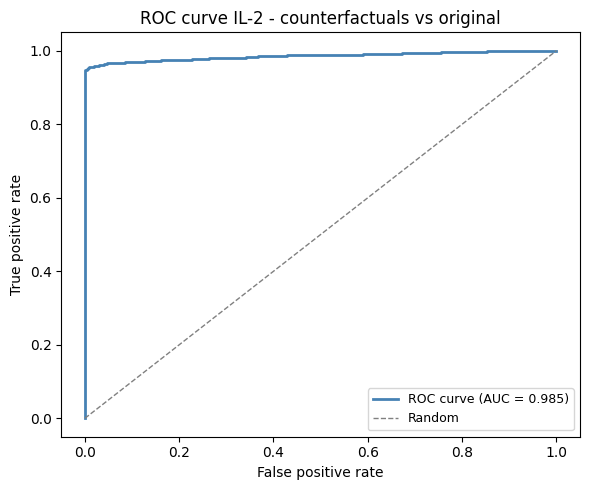

AUC: 0.985


In [10]:
cfs_classifier.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in cfs_test_dataloader:
        x = x.to(analyzer.device)
        logits = cfs_classifier(x)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y[0].argmax(dim=1).cpu().numpy())  # one-hot to int

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# for binary classifier: use probability of positive class
fpr, tpr, _ = roc_curve(all_labels, all_probs[:, target_idx])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC curve {key} - counterfactuals vs original")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, f"roc_curve_{key}.png"), dpi=300)
plt.show()

print(f"AUC: {roc_auc:.3f}")

### 3.4 MMD

In [ ]:
ctrl_mmd = ctrl_mmd_dists(analyzer, key=key, log1p_transform=False)
print(f"Control MMD (random split): {ctrl_mmd:.4f}")
global_mmd, mmd_per_group = mmd_dists(
    analyzer, key=key, sigma=1.0, cf_fn=generate_counterfactuals_scgen, log1p_transform=False
)
print(f"Global MMD for {key}: {global_mmd}")

Control MMD (random split): 0.0004
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


...

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:24<00:00,  2.25s/it]

Global MMD for IL-2: 0.0046797990798950195


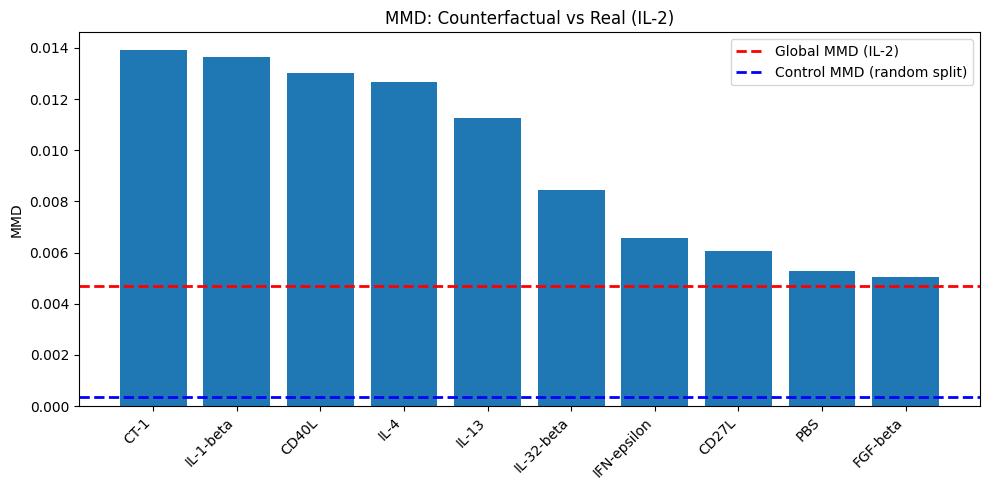

In [ ]:
plot_mmd_dists(analyzer, ctrl_mmd, global_mmd, mmd_per_group, key=key)

### 3.5 Mean Expressions

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


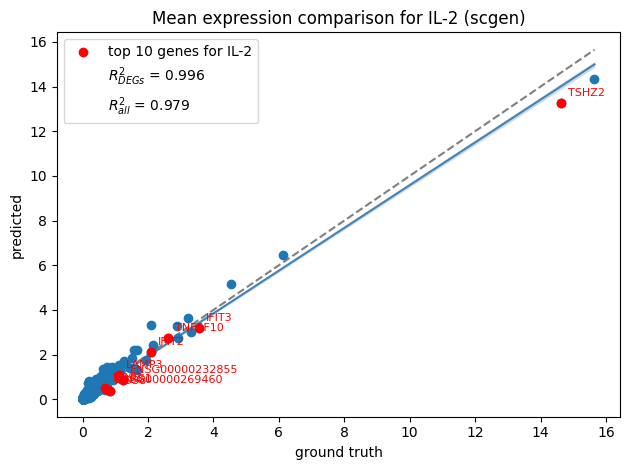

In [12]:
plot_mean_expression_comparison(analyzer, key=key, top_n=10, cfs_fn=generate_counterfactuals_scgen, log1p_transform=False, method="scgen")

### 3.6 Violin Plots

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


...

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/src/analysis/cf_expressions.py:281: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


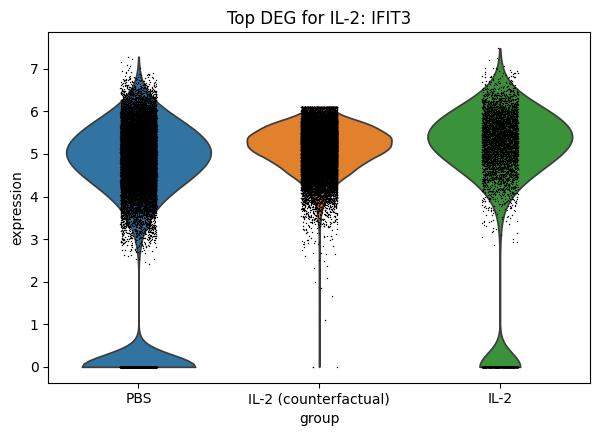

In [14]:
plot_top_deg_violin(analyzer, key=key, cfs_fn=generate_counterfactuals_scgen, log1p_transform=True)

## 4. OOD

In [6]:
print(f"Holdout combo: {HOLDOUT_COMBO}")
print(f"Combo categories: {combo_categories}")

estimate_leftout_combo_mean(
    model=analyzer.model,
    combo_categories=combo_categories,
    conditions=combo_conditions,
    holdout_combo=HOLDOUT_COMBO,
    condition_key=labels_key,
    control_label=control_label,
    cell_type_key="cell_type",
)

Holdout combo: {'cytokine': 'IL-2', 'cell_type': 'CD8 Memory'}
Combo categories: ['CD27L__B Intermediate/Memory', 'CD27L__B Naive', 'CD27L__CD14 Mono', 'CD27L__CD16 Mono', 'CD27L__CD4 Memory', 'CD27L__CD4 Naive', 'CD27L__CD8 Memory', 'CD27L__CD8 Naive', 'CD27L__HSPC', 'CD27L__ILC', 'CD27L__MAIT', 'CD27L__NK', 'CD27L__NK CD56bright', 'CD27L__NKT', 'CD27L__Plasmablast', 'CD27L__Treg', 'CD27L__cDC', 'CD27L__pDC', 'CD40L__B Intermediate/Memory', 'CD40L__B Naive', 'CD40L__CD14 Mono', 'CD40L__CD16 Mono', 'CD40L__CD4 Memory', 'CD40L__CD4 Naive', 'CD40L__CD8 Memory', 'CD40L__CD8 Naive', 'CD40L__HSPC', 'CD40L__ILC', 'CD40L__MAIT', 'CD40L__NK', 'CD40L__NK CD56bright', 'CD40L__NKT', 'CD40L__Plasmablast', 'CD40L__Treg', 'CD40L__cDC', 'CD40L__pDC', 'CT-1__B Intermediate/Memory', 'CT-1__B Naive', 'CT-1__CD14 Mono', 'CT-1__CD16 Mono', 'CT-1__CD4 Memory', 'CT-1__CD4 Naive', 'CT-1__CD8 Memory', 'CT-1__CD8 Naive', 'CT-1__HSPC', 'CT-1__ILC', 'CT-1__MAIT', 'CT-1__NK', 'CT-1__NK CD56bright', 'CT-1__NKT', '

NameError: name 'analyzer' is not defined

### 4.1 Sampling strategy 1: Normal around the estimated mean

Draws fresh latent points from an isotropic Normal centered on the mean estimated above,
then decodes via `module.generative()["px"]` directly - the same raw-count-scale decode
step `.predict()` uses internally (`forward()` would instead route this through its
log1p-only bridge, landing on a different scale than `adata.X`/section 3's real-count
comparisons).

In [ ]:
n_samples = 500
sigma = 1.0

target_idx = combo_categories.index("__".join(HOLDOUT_COMBO[c] for c in combo_conditions))
mean = analyzer.model.means[target_idx].detach()

z = mean.unsqueeze(0) + sigma * torch.randn(
    n_samples, mean.shape[0], device=mean.device, dtype=mean.dtype
)

with torch.no_grad():
    x = analyzer.model.module.generative(z)["px"].clamp(min=0).cpu().numpy()

adata_ood_normal = ad.AnnData(
    X=x,
    obs=pd.DataFrame({k: [v] * n_samples for k, v in HOLDOUT_COMBO.items()}),
    var=adata.var.copy(),
)
adata_ood_normal

AnnData object with n_obs × n_vars = 500 × 1937
    obs: 'cytokine', 'cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_counts', 'highly_variable_rank', 'variances', 'variances_norm'

### 4.2 Sampling strategy 2: scGen's official ctrl -> stim latent arithmetic

Uses `SCGENMixturePriorWrapper.predict()` (passthrough to `scgen.SCGEN.predict`) with
`celltype_to_predict` instead of `adata_to_predict` - the official leave-one-combo/
cell-type-out pattern from scGen's own tutorial. Internally this extracts the real
*control* cells of the held-out cell type from the model's own registered `train_adata`
(`extractor(...)`, requires those control rows to exist - true here since only the
`(cytokine, cell_type)` pair was held out, not the whole cell type), computes
`delta = mean(stim latent) - mean(ctrl latent)` pooled over every other cell type present
in `train_adata` (`restrict_arithmetic_to="all"`, class-balanced via scGen's `balancer`),
and decodes `delta + encode(control cells)` - i.e. the same encode/shift/decode idea as
`estimate_leftout_combo_mean`'s shift, computed scGen's own validated way instead of
through the mixture-prior `.means`.

In [ ]:
adata_ood_shift, delta = analyzer.model.predict(
    ctrl_key=control_label,
    stim_key=HOLDOUT_COMBO[labels_key],
    celltype_to_predict=HOLDOUT_COMBO["cell_type"],
)
# obs is copied from the real control cells .predict() started from, so still says
# control_label - overwrite to reflect what these rows actually are: predictions at
# HOLDOUT_COMBO's treatment
adata_ood_shift.obs[labels_key] = HOLDOUT_COMBO[labels_key]
adata_ood_shift

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 147 × 1937
    obs: 'cell_type', 'cytokine', 'n_cells', 'cluster_idx', '_scvi_batch', '_scvi_labels'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_counts', 'highly_variable_rank', 'variances', 'variances_norm'

### 4.3 Evaluation: MMD and mean expressions

Compares both OOD sampling strategies against the real held-out-combo cells - present in
`analyzer.adata` (the full, un-holdout-filtered adata) even though the model never trained
on them. `scoped_analyzer_for_combo` restricts `.adata` to just the held-out cell type so
`analyzer.labels_key` (the single "cytokine" column) alone resolves to this combo, letting
the same MMD and mean-expression helpers used for the regular counterfactual evaluation
(section 3) be reused unchanged via `cfs_fn_from_adata`. Both prediction sets and
`analyzer.adata` are raw counts here, so `log1p_transform=False` throughout, matching
section 3's own convention for this model.

In [ ]:
ood_key = HOLDOUT_COMBO[labels_key]

scoped_analyzer = scoped_analyzer_for_combo(
    analyzer,
    HOLDOUT_COMBO,
    conditions=combo_conditions,
    condition_key=labels_key,
    cell_type_key="cell_type",
)

ood_predictions = {
    "Normal": adata_ood_normal,
    "Shift": adata_ood_shift,
}

print(f"Real held-out cells found: {scoped_analyzer.adata.obs[labels_key].value_counts()[ood_key]}")

Real held-out cells found: 28


100%|████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 34873.28it/s]


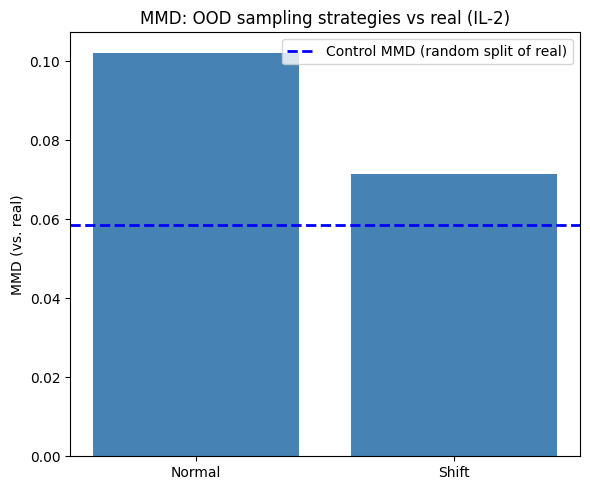

Control MMD (random split of real): 0.0585
{'Normal': 0.10216915607452393, 'Shift': 0.07139730453491211}


In [ ]:
mmd_results, ood_ctrl_mmd = evaluate_leftout_combo_mmd(
    scoped_analyzer, ood_predictions, key=ood_key, plot_dir=analyzer.plot_dir
)
print(f"Control MMD (random split of real): {ood_ctrl_mmd:.4f}")
print(mmd_results)

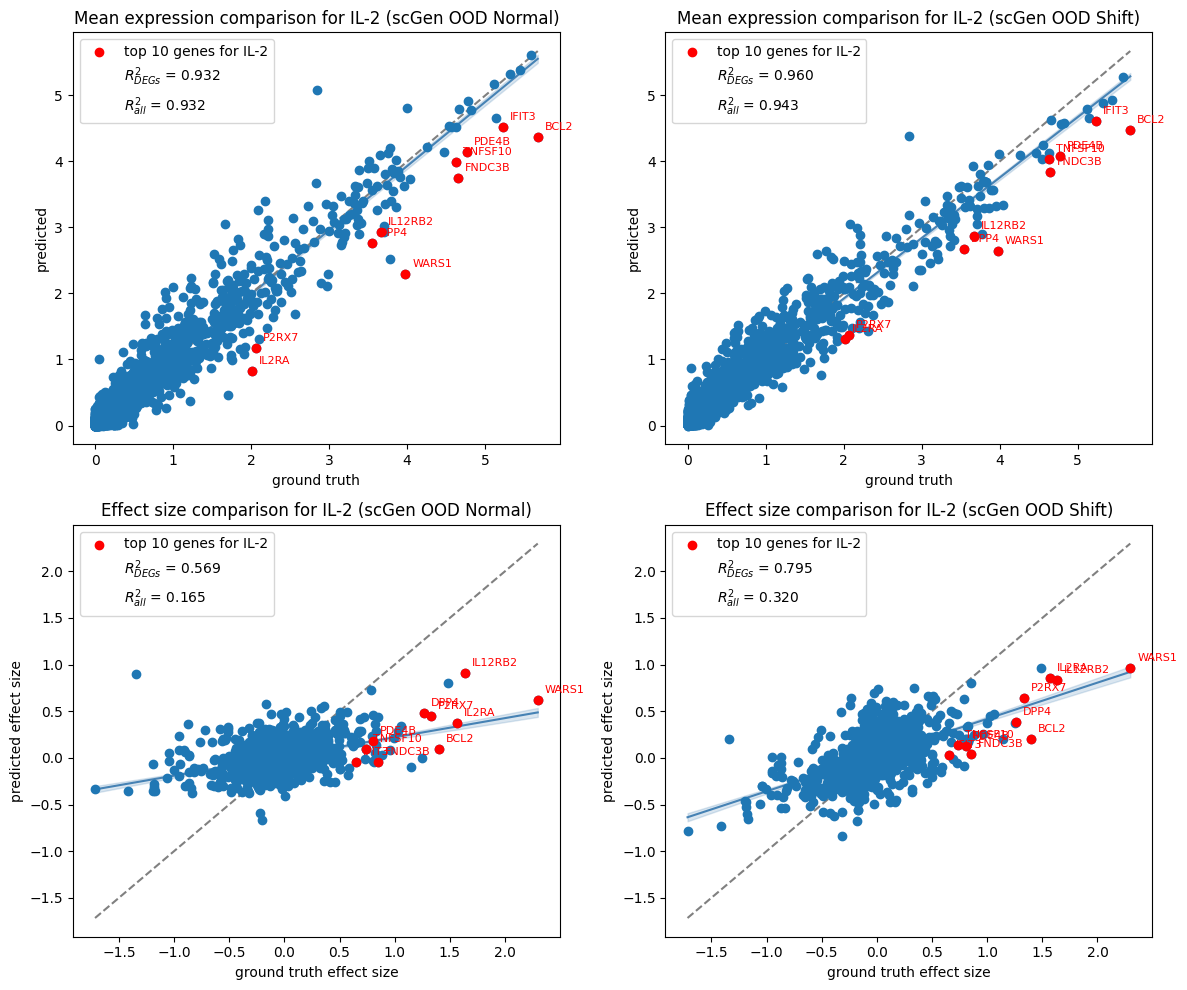

In [ ]:
fig, axes = plt.subplots(2, len(ood_predictions), figsize=(6 * len(ood_predictions), 10))

for col, (name, adata_pred) in enumerate(ood_predictions.items()):
    cfs_fn = cfs_fn_from_adata(adata_pred, source_label=name)

    plot_mean_expression_comparison(
        scoped_analyzer,
        key=ood_key,
        top_n=10,
        cfs_fn=cfs_fn,
        log1p_transform=False,
        method=f"scGen OOD {name}",
        ax=axes[0, col],
    )
    plot_effect_size_comparison(
        scoped_analyzer,
        key=ood_key,
        top_n=10,
        cfs_fn=cfs_fn,
        log1p_transform=False,
        method=f"scGen OOD {name}",
        ax=axes[1, col],
    )

plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, f"leftout_combo_mean_expression_{ood_key}.png"), dpi=300)
plt.show()